In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer 
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve
from pathlib import Path
from scipy.optimize import minimize_scalar
from scipy.special import softmax
import xgboost as xgb
import optuna

CLASS_ORDER = np.array([0, 1, 2], dtype=int)
CLASS_NAMES = {
    0: "Home win",
    1: "Draw",
    2: "Away win",
}

In [2]:
#Loss Functions

def validate_labels(y, split_name, require_all_classes=True):
    """Fail early when winner_code does not follow the agreed convention."""
    values = set(pd.Series(y).dropna().astype(int).unique())
    expected = set(CLASS_ORDER.tolist())

    unexpected = values - expected
    if unexpected:
        raise ValueError(
            f"{split_name} contains unexpected winner_code values: "
            f"{sorted(unexpected)}. Expected only {sorted(expected)}."
        )

    if require_all_classes:
        missing = expected - values
        if missing:
            raise ValueError(
                f"{split_name} is missing classes {sorted(missing)}. "
                "All three classes are required for model training."
            )
        
def align_predict_proba(model, raw_probs):
    """Return probability columns in fixed order: home, draw, away."""
    model_classes = np.asarray(model.classes_, dtype=int)
    missing = set(CLASS_ORDER.tolist()) - set(model_classes.tolist())
    if missing:
        raise ValueError(
            f"The fitted model is missing probability columns for classes {sorted(missing)}."
        )

    class_to_column = {
        class_id: column_index
        for column_index, class_id in enumerate(model_classes)
    }
    return np.column_stack(
        [raw_probs[:, class_to_column[class_id]] for class_id in CLASS_ORDER]
    )
        
def multiclass_brier(y_true, probs):
    y_true = np.asarray(y_true, dtype=int)
    validate_labels(y_true, "Brier-score labels")
    y_onehot = np.eye(len(CLASS_ORDER))[y_true]
    return np.mean(np.sum((probs - y_onehot) ** 2, axis=1))


def rps_score_raw(y_true, probs):
    """Unnormalized cumulative RPS sum, retained for backward comparison."""
    y_true = np.asarray(y_true, dtype=int)
    validate_labels(y_true, "RPS labels")
    actual = np.eye(len(CLASS_ORDER))[y_true]

    pred_cum = np.cumsum(probs[:, :-1], axis=1)
    actual_cum = np.cumsum(actual[:, :-1], axis=1)
    return np.mean(np.sum((pred_cum - actual_cum) ** 2, axis=1))


def rps_score(y_true, probs):
    """Standard normalized RPS for ordered outcomes home/draw/away."""
    return rps_score_raw(y_true, probs) / (len(CLASS_ORDER) - 1)



def calibration_table(y_true, probs, class_id, n_bins=10):
    frame = pd.DataFrame({
        "probability": probs[:, class_id],
        "actual": (np.asarray(y_true) == class_id).astype(int),
    })

    frame["bin"] = pd.qcut(
        frame["probability"],
        q=n_bins,
        duplicates="drop",
    )

    return (
        frame.groupby("bin", observed=True)
        .agg(
            count=("actual", "size"),
            mean_probability=("probability", "mean"),
            observed_frequency=("actual", "mean"),
        )
        .reset_index()
    )

def calibration_score_plot(y_test, probs, n_bins=10):

    calibration_results = {}

    plt.figure(figsize=(8, 6))

    for class_id, name in enumerate(
        ["Home win", "Draw", "Away win"]
    ):

        y_binary = (y_test == class_id).astype(int)

        prob_true, prob_pred = calibration_curve(
            y_binary,
            probs[:, class_id],
            n_bins=n_bins,
            strategy="uniform"
        )

        calibration_results[name] = {
            "predicted_probability": prob_pred,
            "observed_frequency": prob_true
        }

        plt.plot(
            prob_pred,
            prob_true,
            marker="o",
            label=name
        )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration"
    )

    plt.title("Calibration Curve: Football Win/Draw/Loss Model")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed frequency")
    plt.legend()
    plt.grid(True)
    plt.show()

    return calibration_results



def apply_temperature(probabilities, temperature):
    """
    Apply multiclass temperature scaling.

    Using log(probability) is equivalent to using the original logits
    up to an observation-specific additive constant.
    """
    probabilities = np.asarray(probabilities, dtype=float)

    if temperature <= 0:
        raise ValueError("temperature must be positive.")

    clipped = np.clip(probabilities, 1e-15, 1.0)
    log_probabilities = np.log(clipped)

    return softmax(log_probabilities / temperature, axis=1)


def fit_temperature(y_calibration, uncalibrated_probabilities):
    """
    Fit temperature using only the chronological calibration set.
    """

    def calibration_objective(log_temperature):
        temperature = np.exp(log_temperature)

        calibrated = apply_temperature(
            uncalibrated_probabilities,
            temperature,
        )

        return log_loss(
            y_calibration,
            calibrated,
            labels=CLASS_ORDER,
        )

    result = minimize_scalar(
        calibration_objective,
        bounds=(np.log(0.05), np.log(20.0)),
        method="bounded",
    )

    if not result.success:
        raise RuntimeError(
            f"Temperature optimization failed: {result.message}"
        )

    return float(np.exp(result.x))

In [3]:
features = pd.read_csv("stored_features/match_features_c_25_mu1_0.20_mu2_0.10.csv")

In [4]:
features["date"] = pd.to_datetime(features["date"], errors="raise")
features = (
    features.loc[
        (features["date"] < pd.Timestamp("2026-06-01"))
        & (features["date"] > pd.Timestamp("1950-01-01"))
    ]
    .sort_values(by="date", ascending=True)
    .reset_index(drop=True)
)


In [5]:
print("winner_code mapping: 0 = home win, 1 = draw, 2 = away win")
print(features["winner_code"].value_counts(dropna=False).sort_index())
validate_labels(features["winner_code"], "Full dataset", require_all_classes=False)


winner_code mapping: 0 = home win, 1 = draw, 2 = away win
winner_code
0    15824
1     9994
2    16579
Name: count, dtype: int64


In [6]:
assert features["date"].is_monotonic_increasing, "The dataset is not sorted by date."

In [7]:
features.columns

Index(['match_id', 'date', 'home_team', 'away_team', 'home_score',
       'away_score', 'winner', 'winner_code', 'home_neutral',
       'home_ppg_last_5', 'home_avg_goals_scored_last_5',
       'home_avg_goals_conceded_last_5', 'home_clean_sheets_rate_last_5',
       'home_avg_goal_difference_last_5', 'home_avg_goal_difference_last_10',
       'home_failed_score_rate_last_5', 'home_over_2_5_rate_last_5',
       'home_over_3_5_rate_last_5', 'home_under_1_5_rate_last_5',
       'home_days_since_last_game', 'home_pi_home_rating',
       'home_pi_away_rating', 'home_pi_expected_gd', 'home_pi_diff',
       'away_ppg_last_5', 'away_avg_goals_scored_last_5',
       'away_avg_goals_conceded_last_5', 'away_clean_sheets_rate_last_5',
       'away_avg_goal_difference_last_5', 'away_avg_goal_difference_last_10',
       'away_failed_score_rate_last_5', 'away_over_2_5_rate_last_5',
       'away_over_3_5_rate_last_5', 'away_under_1_5_rate_last_5',
       'away_days_since_last_game', 'away_pi_home_rat

In [8]:
features = features.drop(
    columns=[
        "match_id",
        "date",
        "home_team",
        "away_team",
        "home_score",
        "away_score",
        "winner",
        #"home_avg_goal_difference_last_10",
        #"away_avg_goal_difference_last_10",
        "home_failed_score_rate_last_5",
        "away_failed_score_rate_last_5",
        #"home_days_since_last_game",
        #"away_days_since_last_game",
        "diff_under_1_5_rate",
        "home_over_2_5_rate_last_5",
        "away_over_2_5_rate_last_5",
        "home_over_3_5_rate_last_5",
        "away_over_3_5_rate_last_5",
        "diff_over_2_5_rate",
        "home_under_1_5_rate_last_5",
        "away_under_1_5_rate_last_5",
        #"home_pi_expected_gd",
        #"away_pi_expected_gd",
    ]
)


In [9]:
# Preserve the final 20% as a true chronological test set.
# The first 80% is split again into training and validation data for Optuna.
y = features["winner_code"].astype(int)
X = features.drop(columns=["winner_code"])

if len(features) < 20:
    raise ValueError("The dataset is too small for a train/validation/test time split.")

test_start = int(len(features) * 0.80)
calibration_start = int(len(features) * 0.65)

X_train_val = X.iloc[:test_start].copy()
Y_train = y.iloc[:test_start].copy()

X_calibration_raw = X.iloc[calibration_start:test_start].copy()
Y_calibration = y.iloc[calibration_start:test_start].copy()

X_test = X.iloc[test_start:].copy()
Y_test = y.iloc[test_start:].copy()

validate_labels(
    Y_train,
    "Development set",
    require_all_classes=True,
)

validate_labels(
    Y_calibration,
    "Calibration set",
    require_all_classes=True,
)

validate_labels(
    Y_test,
    "Test set",
    require_all_classes=False,
)

print("Development rows:", len(X_train_val))
print("Calibration rows:", len(X_calibration_raw))
print("Test rows:", len(X_test))


Development rows: 33917
Calibration rows: 6359
Test rows: 8480


In [10]:
tscv = TimeSeriesSplit(n_splits=12)

def objective(trial):
    params = {
        "objective": "multi:softprob",
        "num_class": len(CLASS_ORDER),
        "eval_metric": "mlogloss",
        "random_state": 42,

        "n_estimators": trial.suggest_int(
            "n_estimators", low=200, high=800, step=20
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate", low=0.03, high=0.17, log=True
        ),
        "max_depth": trial.suggest_int("max_depth", low=2, high=6, step=1),
        "min_child_weight": trial.suggest_int(
            "min_child_weight", low=1, high=15, step=1
        ),
        "gamma": trial.suggest_float("gamma", low=0.0, high=5.0, step=0.1),
        "subsample": trial.suggest_float(
            "subsample", low=0.6, high=1.0, step=0.05
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", low=0.6, high=1.0, step=0.05
        ),
        "colsample_bylevel": trial.suggest_float(
            "colsample_bylevel", low=0.6, high=1.0, step=0.05
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda", low=1.0, high=20.0, log=True
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha", low=0.0, high=5.0, step=0.1
        ),
        "tree_method": "hist",
        "n_jobs": -1,
    }

    fold_rps_scores = []
    fold_brier_scores = []
    fold_log_losses = []

    for fold_number, (train_idx, val_idx) in enumerate(
        tscv.split(X_train_val),
        start=1,
    ):
        # Chronological fold
        fold_X_train_raw = X_train_val.iloc[train_idx]
        fold_X_val_raw = X_train_val.iloc[val_idx]

        fold_y_train = Y_train.iloc[train_idx]
        fold_y_val = Y_train.iloc[val_idx]

        # Fit preprocessing only on the current fold's training portion
        # imputer = SimpleImputer(strategy="median")

        # fold_X_train = imputer.fit_transform(fold_X_train_raw)
        # fold_X_val = imputer.transform(fold_X_val_raw)

        # A separate model must be fitted for every fold
        model = xgb.XGBClassifier(**params)

        model.fit(
            fold_X_train_raw,
            fold_y_train,
            eval_set=[(fold_X_val_raw, fold_y_val)],
            verbose=False,
        )

        raw_probs = model.predict_proba(fold_X_val_raw)
        probs = align_predict_proba(model, raw_probs)

        fold_rps = rps_score(fold_y_val, probs)
        fold_brier = multiclass_brier(fold_y_val, probs)
        fold_logloss = log_loss(
            fold_y_val,
            probs,
            labels=CLASS_ORDER,
        )

        fold_rps_scores.append(fold_rps)
        fold_brier_scores.append(fold_brier)
        fold_log_losses.append(fold_logloss)

        # Allow Optuna to stop unpromising trials
        running_rps = float(np.mean(fold_rps_scores))
        trial.report(running_rps, step=fold_number)

        if trial.should_prune():
            raise optuna.TrialPruned()

    mean_rps = float(np.mean(fold_rps_scores))
    std_rps = float(np.std(fold_rps_scores))
    mean_brier = float(np.mean(fold_brier_scores))
    mean_logloss = float(np.mean(fold_log_losses))

    trial.set_user_attr("rps_std", std_rps)
    trial.set_user_attr("mean_brier", mean_brier)
    trial.set_user_attr("mean_logloss", mean_logloss)

    print(
        f"Trial: {trial.number} "
        f"- Mean RPS: {mean_rps:.5f} "
        f"- RPS std: {std_rps:.5f} "
        f"- Mean Brier: {mean_brier:.5f} "
        f"- Mean log loss: {mean_logloss:.5f}"
    )

    return mean_rps


In [11]:
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=10,
        n_warmup_steps=2,
    ),
)

study.optimize(
    objective,
    n_trials=40,
    show_progress_bar=True,
)

[I 2026-07-15 00:32:13,076] A new study created in memory with name: no-name-230676a4-9d84-4bf7-9e8b-98e76b31e8bf


  0%|          | 0/40 [00:00<?, ?it/s]

Trial: 0 - Mean RPS: 0.19153 - RPS std: 0.00664 - Mean Brier: 0.56889 - Mean log loss: 0.96359
[I 2026-07-15 00:32:47,574] Trial 0 finished with value: 0.19152871472365465 and parameters: {'n_estimators': 420, 'learning_rate': 0.15607043643146598, 'max_depth': 5, 'min_child_weight': 9, 'gamma': 0.7000000000000001, 'subsample': 0.65, 'colsample_bytree': 0.6, 'colsample_bylevel': 0.95, 'reg_lambda': 6.054365855469246, 'reg_alpha': 3.6}. Best is trial 0 with value: 0.19152871472365465.
Trial: 1 - Mean RPS: 0.19132 - RPS std: 0.00662 - Mean Brier: 0.56813 - Mean log loss: 0.96215
[I 2026-07-15 00:33:05,541] Trial 1 finished with value: 0.19132406880532096 and parameters: {'n_estimators': 200, 'learning_rate': 0.1613545366377691, 'max_depth': 6, 'min_child_weight': 4, 'gamma': 0.9, 'subsample': 0.65, 'colsample_bytree': 0.7, 'colsample_bylevel': 0.8, 'reg_lambda': 3.6473162849112093, 'reg_alpha': 1.4000000000000001}. Best is trial 1 with value: 0.19132406880532096.
Trial: 2 - Mean RPS: 0.18

In [12]:
print(study.best_params)

{'n_estimators': 720, 'learning_rate': 0.037973275148548945, 'max_depth': 6, 'min_child_weight': 4, 'gamma': 2.2, 'subsample': 0.75, 'colsample_bytree': 0.7, 'colsample_bylevel': 0.6, 'reg_lambda': 2.7809682820671546, 'reg_alpha': 3.4000000000000004}


In [13]:
best_params = study.best_params

# After model selection, refit preprocessing on train + validation only.
X_train_raw = X_train_val.copy()
Y_train_raw = Y_train.copy()

#X_train_val_raw = pd.concat([X_train_raw, X_val_raw], axis=0)
#Y_train_val = pd.concat([Y_train, Y_val], axis=0)

#final_imputer = SimpleImputer(strategy="median")
# final_scaler = StandardScaler()

# X_train_val = pd.DataFrame(
#     final_imputer.fit_transform(X_train_raw),
#     columns=X_train_raw.columns,
#     index=X_train_raw.index,
# )
# X_test = pd.DataFrame(
#     final_imputer.transform(X_test_raw),
#     columns=X_test_raw.columns,
#     index=X_test_raw.index,
# )

# X_train_val = pd.DataFrame(
#     final_scaler.fit_transform(X_train_val_imputed),
#     columns=X_train_val_imputed.columns,
#     index=X_train_val_imputed.index,
# )
# X_test = pd.DataFrame(
#     final_scaler.transform(X_test_imputed),
#     columns=X_test_imputed.columns,
#     index=X_test_imputed.index,
# )

final_model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=len(CLASS_ORDER),
    eval_metric="mlogloss",
    random_state=42,
    **best_params,
)

final_model.fit(
    X_train_val,
    Y_train_raw,
    eval_set=[(X_train_val, Y_train_raw)],
    verbose=False,
)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,0.6
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load

In [14]:
calibration_probs_raw = align_predict_proba(
    final_model,
    final_model.predict_proba(X_calibration_raw),
)

temperature = fit_temperature(
    Y_calibration,
    calibration_probs_raw,
)

calibration_probs_calibrated = apply_temperature(
    calibration_probs_raw,
    temperature,
)

print(f"Selected temperature: {temperature:.4f}")

Selected temperature: 0.8505


In [15]:
probs = align_predict_proba(
    final_model,
    final_model.predict_proba(X_test),
)

results = {
    "log_loss": log_loss(Y_test, probs, labels=CLASS_ORDER),
    "brier_score": multiclass_brier(Y_test, probs),
    "rps_score": rps_score(Y_test, probs),
}


predicted_codes = CLASS_ORDER[np.argmax(probs, axis=1)]
prediction_output = pd.DataFrame(
    {
        "actual_code": Y_test.to_numpy(),
        "predicted_code": predicted_codes,
        "actual_result": [CLASS_NAMES[int(code)] for code in Y_test],
        "predicted_result": [CLASS_NAMES[int(code)] for code in predicted_codes],
        "prob_home_win": probs[:, 0],
        "prob_draw": probs[:, 1],
        "prob_away_win": probs[:, 2],
    },
    index=Y_test.index,
)

display(prediction_output)


,actual_code,predicted_code,actual_result,predicted_result,prob_home_win,prob_draw,prob_away_win
33917,0,2,Home win,Away win,0.229096,0.285255,0.485649
33918,2,2,Away win,Away win,0.345983,0.293180,0.360837
33919,1,0,Draw,Home win,0.677710,0.218817,0.103473
33920,2,2,Away win,Away win,0.269577,0.285764,0.444660
33921,0,0,Home win,Home win,0.404949,0.293581,0.301470
...,...,...,...,...,...,...,...
42392,2,2,Away win,Away win,0.187699,0.220074,0.592227
42393,2,2,Away win,Away win,0.191339,0.260095,0.548567
42394,2,0,Away win,Home win,0.588430,0.259478,0.152091
42395,2,2,Away win,Away win,0.154106,0.256753,0.589141


In [16]:
test_probs_raw = align_predict_proba(
    final_model,
    final_model.predict_proba(X_test),
)

test_probs_calibrated = apply_temperature(
    test_probs_raw,
    temperature,
)

assert np.allclose(
    test_probs_calibrated.sum(axis=1),
    1.0,
    atol=1e-10,
)

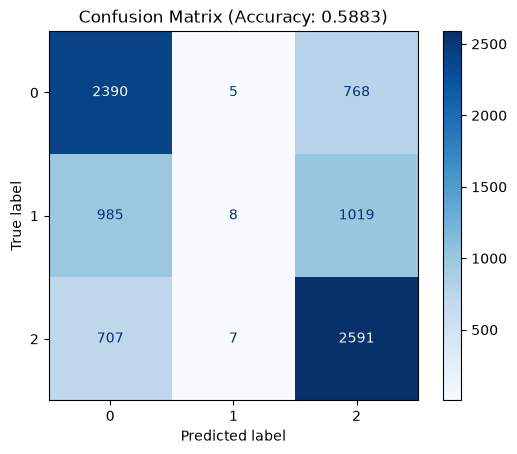

In [17]:
acc_score = accuracy_score(Y_test, predicted_codes)
cm = confusion_matrix(Y_test, predicted_codes, labels=CLASS_ORDER)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_ORDER)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix (Accuracy: {acc_score:.4f})")
plt.show()

In [18]:
def multiclass_brier(y_true, probs):
    y_true = np.asarray(y_true, dtype=int)

    validate_labels(y_true,"Brier-score labels",require_all_classes=False,)
    y_onehot = np.eye(len(CLASS_ORDER))[y_true]

    return float(np.mean(np.sum((probs - y_onehot) ** 2, axis=1)))


def rps_score_raw(y_true, probs):
    y_true = np.asarray(y_true, dtype=int)

    validate_labels(y_true,"RPS labels",require_all_classes=False,)
    actual = np.eye(len(CLASS_ORDER))[y_true]
    pred_cum = np.cumsum(probs[:, :-1], axis=1)
    actual_cum = np.cumsum(actual[:, :-1], axis=1)
    return float(np.mean(np.sum((pred_cum - actual_cum) ** 2, axis=1)))

def probability_metric_table(y_true, raw_probs, calibrated_probs):
    rows = []

    for name, probabilities in [
        ("Uncalibrated", raw_probs),
        ("Temperature calibrated", calibrated_probs),
    ]:
        rows.append(
            {
                "model": name,
                "log_loss": log_loss(
                    y_true,
                    probabilities,
                    labels=CLASS_ORDER,
                ),
                "multiclass_brier": multiclass_brier(
                    y_true,
                    probabilities,
                ),
                "rps": rps_score(
                    y_true,
                    probabilities,
                ),
            }
        )

    return pd.DataFrame(rows).set_index("model")

In [19]:
display(
    probability_metric_table(
        Y_calibration,
        calibration_probs_raw,
        calibration_probs_calibrated,
    )
)

,log_loss,multiclass_brier,rps
model,,,
Uncalibrated,0.881037,0.519915,0.174866
Temperature calibrated,0.877504,0.518459,0.174272


In [20]:
display(probability_metric_table(
    Y_test,
    test_probs_raw,
    test_probs_calibrated,
))

,log_loss,multiclass_brier,rps
model,,,
Uncalibrated,0.894443,0.527513,0.175805
Temperature calibrated,0.895320,0.528391,0.175972
